In [ ]:
# 匯入 Keras 所需模組
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten

# =============================================
# 1️⃣ 建立一個 Sequential（序列式）模型
# =============================================
model = Sequential()

# Flatten 層：將輸入的 28x28 影像攤平成一維向量 (784 維)
# MNIST 每張圖是 28x28 的灰階圖，Flatten 會轉換成一維資料
model.add(Flatten())

# Dense 層（全連接層）：第一層隱藏層，含 32 個神經元，使用 ReLU 激活函數
# input_dim=784 表示輸入層有 784 個輸入（即 28x28 攤平後的像素數）
model.add(Dense(32, activation='relu', input_dim=784))

# Dense 層（輸出層）：共有 10 個神經元，對應數字 0~9
# 使用 sigmoid 激活函數（實際上分類問題通常用 softmax 更好）
model.add(Dense(10, activation='sigmoid'))

# 編譯模型：設定優化器、損失函數與評估指標
# optimizer='rmsprop'：使用 RMSProp 優化器
# loss='sparse_categorical_crossentropy'：適合整數標籤分類問題
# metrics=['accuracy']：在訓練與測試時顯示準確率
model.compile(optimizer='rmsprop',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
載入 MNIST 手寫數字資料集
# =============================================
mnist = keras.datasets.mnist

# 透過 Keras 直接下載 MNIST 資料
# train_data：訓練影像資料，形狀為 (60000, 28, 28)
# train_label：訓練標籤資料（對應 0~9）
# test_data：測試影像資料，形狀為 (10000, 28, 28)
# test_label：測試標籤資料
(train_data, train_label), (test_data, test_label) = mnist.load_data()

In [ ]:
查看資料集的結構與型態
# =============================================

# 顯示訓練資料型別（應為 numpy 陣列）
print(type(train_data))

# 顯示訓練資料形狀：(60000, 28, 28)
# 代表共有 60000 張影像，每張 28x28 像素
print(train_data.shape)

# 顯示訓練標籤型別（同樣是 numpy 陣列）
print(type(train_label))

# 顯示訓練標籤形狀：(60000,)
# 表示每張影像有一個對應的數字標籤（0~9）
print(train_label.shape)

# 顯示測試資料與標籤的形狀
print(test_data.shape)
print(test_label.shape)

# 輸出結果示例：
# <class 'numpy.ndarray'>
# (60000, 28, 28)
# <class 'numpy.ndarray'>
# (60000,)
# (10000, 28, 28)
# (10000,)

<class 'numpy.ndarray'>
(60000, 28, 28)
<class 'numpy.ndarray'>
(60000,)
(10000, 28, 28)
(10000,)


In [ ]:
 檢查單筆資料內容
# =============================================

# 顯示第一筆訓練資料的標籤（例如 5）
print(train_label[0])

# 顯示第一張訓練影像的像素矩陣（28x28 灰階像素值，範圍 0~255）
print(train_data[0])

5
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 

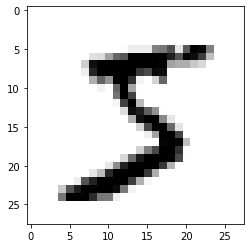

In [5]:
import matplotlib.pyplot as plt
plt.imshow(train_data[0], cmap='binary')
plt.show()

In [6]:
model.fit(train_data,train_label,epochs=20,batch_size=512)

Epoch 1/20
118/118 [==============================] - 2s 10ms/step - loss: 5.5679 - accuracy: 0.4254
Epoch 2/20
118/118 [==============================] - 1s 10ms/step - loss: 1.1698 - accuracy: 0.6519
Epoch 3/20
118/118 [==============================] - 1s 10ms/step - loss: 0.8294 - accuracy: 0.8076
Epoch 4/20
118/118 [==============================] - 1s 10ms/step - loss: 0.6627 - accuracy: 0.8563
Epoch 5/20
118/118 [==============================] - 1s 11ms/step - loss: 0.5409 - accuracy: 0.8754
Epoch 6/20
118/118 [==============================] - 1s 11ms/step - loss: 0.4570 - accuracy: 0.8899
Epoch 7/20
118/118 [==============================] - 1s 10ms/step - loss: 0.3965 - accuracy: 0.9010
Epoch 8/20
118/118 [==============================] - 1s 11ms/step - loss: 0.3584 - accuracy: 0.9097
Epoch 9/20
118/118 [==============================] - 1s 11ms/step - loss: 0.3207 - accuracy: 0.9178
Epoch 10/20
118/118 [==============================] - 1s 12ms/step - loss: 0.2997 - accura

In [7]:
score=model.evaluate(test_data, test_label)
print(score[1])

313/313 [==============================] - 1s 2ms/step - loss: 0.3632 - accuracy: 0.9305
0.9304999709129333
